In [254]:
import pandas as pd
import numpy as np
import numpy as np
from scipy.optimize import minimize
from scipy.special import softmax

import importlib

import matplotlib.pyplot as plt

import utility_functions as uf

In [6]:
df_sf = uf.df_topics[["subfield_id", "field_id", "domain_id"]].drop_duplicates().sort_values(["domain_id", "field_id", "subfield_id"])

In [179]:
def get_wass_array(df_sf, weight_list = [1, 0.1, 0.01]):
    n_sf = df_sf.subfield_id.nunique()
    sf_sorted = df_sf.subfield_id.to_list()

    n_fields = df_sf.field_id.nunique()
    fields_sorted = df_sf.field_id.drop_duplicates().to_list()

    n_domains = df_sf.domain_id.nunique()
    domains_sorted = df_sf.domain_id.drop_duplicates().to_list()

    adj_matrix_size = 1 + n_domains + n_fields + n_sf
    adj_int_size = 1 + n_domains + n_fields

    adj_matrix = np.zeros((adj_matrix_size, adj_matrix_size))

    # add root -- domain
    adj_matrix[0, range(1, n_domains+1)] = 1

    # add domain -- field
    for i, domain in enumerate(domains_sorted):
        fields_list = df_sf.query("domain_id == @domain").field_id.drop_duplicates().to_list()
        fields_idx = [1 + n_domains + fields_sorted.index(f) for f in fields_list]
        adj_matrix[1 + i, fields_idx] = 1

    # add field -- subfield
    for i, field in enumerate(fields_sorted):
        sf_list = df_sf.query("field_id == @field").subfield_id.drop_duplicates().to_list()
        sf_idx = [adj_int_size + sf_sorted.index(sf) for sf in sf_list]
        adj_matrix[1 + n_domains + i, sf_idx] = 1

    adj_int = adj_matrix[:1+n_domains+n_fields, :1+n_domains+n_fields]
    adj_leaves = adj_matrix[:1+n_domains+n_fields, 1+n_domains+n_fields:]

    q11 = np.linalg.inv(np.eye(adj_int_size) - adj_int)
    q12 = np.matmul(q11, adj_leaves)
    q21 = np.zeros((n_sf, adj_int_size))
    q22 = np.eye(q12.shape[1])

    r1 = np.concatenate([q11, q12], axis=1)
    r2 = np.concatenate([q21, q22], axis=1)
    wass_array = np.concatenate([r1, r2])

    weights = np.array([0] + [weight_list[0]]*n_domains + [weight_list[1]]*n_fields + [weight_list[2]]*n_sf).T
    return np.tile(weights, (wass_array.shape[1], 1)).T * wass_array, adj_int_size

def get_w1_distance_matrix(mu_vector, nu_vector, wass_array):
    return np.sum(np.abs(wass_array @ (mu_vector - nu_vector)))

In [ ]:
wass_array, n_int = get_wass_array(df_sf)
wass_array_short = wass_array[:, n_int:]

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_9942/1204381143.py:35: RuntimeWarning: divide by zero encountered in matmul
  q12 = np.matmul(q11, adj_leaves)
/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_9942/1204381143.py:35: RuntimeWarning: overflow encountered in matmul
  q12 = np.matmul(q11, adj_leaves)
/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_9942/1204381143.py:35: RuntimeWarning: invalid value encountered in matmul
  q12 = np.matmul(q11, adj_leaves)


In [181]:
df_cs = pd.read_csv(uf.PATH+"df_cs_yearly.csv", index_col=[0, 1, 2]).xs((2023, "individual"), level=[1, 2]).T.loc[[str(sf) for sf in sf_sorted]].T
df_prob = df_cs.div(df_cs.sum(axis=1), axis=0).fillna(0)

subfield_tree = uf.get_subfield_tree(uf.df_topics)

In [185]:
c_mu = "US"
c_nu = "CN"

mu_vector = np.array([0]*n_int + df_prob.loc[c_mu].to_list())
nu_vector = np.array([0]*n_int + df_prob.loc[c_nu].to_list())

mu_dict = df_prob.loc[c_mu].to_dict()
nu_dict = df_prob.loc[c_nu].to_dict()

In [186]:
_, _, res1 = uf.get_dist_w1_tree(subfield_tree, mu_dict, nu_dict)
res1

np.float64(0.6181620949227653)

In [187]:
res2 = get_w1_distance_matrix(mu_vector, nu_vector, wass_array)
res2

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_9942/1204381143.py:47: RuntimeWarning: divide by zero encountered in matmul
  return np.sum(np.abs(wass_array @ (mu_vector - nu_vector)))
/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_9942/1204381143.py:47: RuntimeWarning: overflow encountered in matmul
  return np.sum(np.abs(wass_array @ (mu_vector - nu_vector)))
/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_9942/1204381143.py:47: RuntimeWarning: invalid value encountered in matmul
  return np.sum(np.abs(wass_array @ (mu_vector - nu_vector)))


np.float64(0.6181620949227653)

In [190]:
mu_short = np.array(df_prob.loc[c_mu].to_list())
nu_short = np.array(df_prob.loc[c_nu].to_list())

In [195]:
def project_simplex(v):
    """Project vector v onto the probability simplex."""
    n = len(v)
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, n + 1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1)
    return np.maximum(v - theta, 0)

In [236]:
def objective_function(mu, wass_array, wass_list):
    return np.sum(np.sum(np.abs(np.tile(wass_array @ mu, (wass_list.shape[1], 1)).T - wass_list), axis=0))

In [405]:
# --- Objective wrapper (with simplex projection inside) ---
def objective_projected(x, wass_array, wass_list):
    """Project x onto simplex before evaluating — ensures valid distribution."""
    p = project_simplex(x)
    return objective_function(p, wass_array, wass_list)

def objective_softmax(x, wass_array_short, wass_list):
    p = softmax(x)  # always a valid distribution, no need to project
    return objective_projected(p, wass_array_short, wass_list)

In [395]:
def get_barycenter(mu_list, wass_array_short):
    wass_list = wass_array_short @ mu_list.T
    result = minimize(
        fun=objective_softmax,
        x0=np.zeros(mu_list.shape[1]),   # softmax(zeros) = uniform, same starting point
        args=(wass_array_short, wass_list),
        method="L-BFGS-B",
        options={
            "maxiter": 5000,
            "ftol": 1e-9,   # tolerance on f(x)
            "gtol": 1e-6,   # tolerance on gradient norm
            "disp": False,
        }
    )
    return softmax(result.x)

In [396]:
n_subfields = len(df_sf.index)

wass_array, n_int = get_wass_array(df_sf)
wass_array_short = wass_array[:, n_int:]

mu_list = df_prob.values.T
wass_list = wass_array_short @ mu_list

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_9942/1204381143.py:35: RuntimeWarning:

divide by zero encountered in matmul

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_9942/1204381143.py:35: RuntimeWarning:

overflow encountered in matmul

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_9942/1204381143.py:35: RuntimeWarning:

invalid value encountered in matmul

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_9942/140602444.py:7: RuntimeWarning:

divide by zero encountered in matmul

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_9942/140602444.py:7: RuntimeWarning:

overflow encountered in matmul

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_9942/140602444.py:7: RuntimeWarning:

invalid value encountered in matmul



In [397]:
df_cs_yearly = pd.read_csv(uf.PATH+"df_cs_yearly.csv", index_col = [0, 1, 2]).xs("individual", level=2)
df_cs_yearly = df_cs_yearly.T.loc[df_sf.subfield_id.astype(str)].T
year_list = df_cs_yearly.reset_index().year.drop_duplicates().sort_values().to_list()

In [398]:
barycenter_list = []
for year_loop in year_list[-5:]:
    df_prob = df_cs_yearly.xs(year_loop, level=1).div(df_cs_yearly.xs(year_loop, level=1).sum(axis=1), axis=0).fillna(0)
    barycenter_list.append(get_barycenter(df_prob.values, wass_array_short))

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_9942/841104958.py:2: RuntimeWarning:

divide by zero encountered in matmul

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_9942/841104958.py:2: RuntimeWarning:

overflow encountered in matmul

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_9942/841104958.py:2: RuntimeWarning:

invalid value encountered in matmul

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_9942/841104958.py:2: RuntimeWarning:

divide by zero encountered in matmul

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_9942/841104958.py:2: RuntimeWarning:

overflow encountered in matmul

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_9942/841104958.py:2: RuntimeWarning:

invalid value encountered in matmul

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_9942/841104958.py:2: RuntimeWarning:

divide by zero encountered in matmul

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_9942/84110

In [399]:
df_profile = pd.DataFrame(barycenter_list, index=year_list[-5:], columns=df_prob.columns)

In [400]:
importlib.reload(uf)

<module 'utility_functions' from '/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py'>

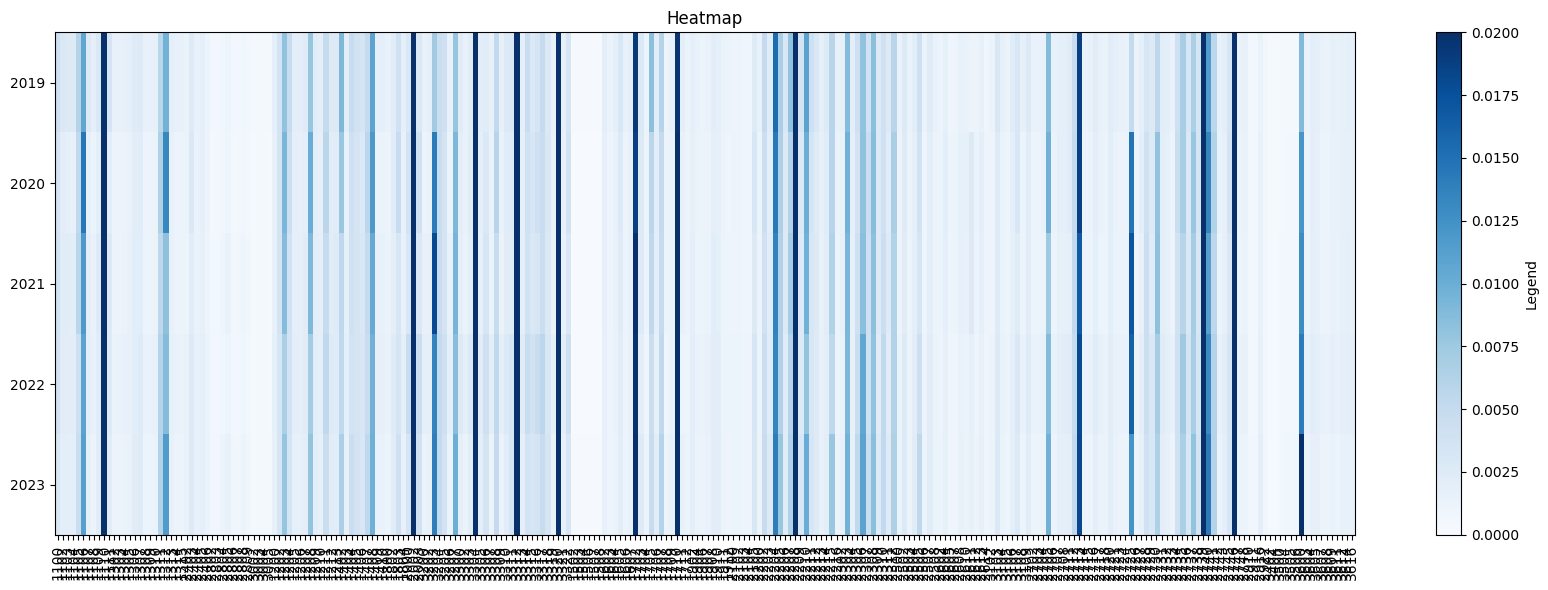

In [401]:
uf.plot_heatmap(df_profile, x_labels=df_profile.columns, y_labels=df_profile.index, z_min=0, z_max=0.02)

In [402]:
df_profile.loc[2023].sort_values(ascending=False).head(10)

3312    0.062458
3304    0.056381
2002    0.031682
3320    0.031093
2746    0.029442
1110    0.026291
2208    0.024644
1710    0.021925
1702    0.021907
2739    0.021700
Name: 2023, dtype: float64

In [403]:
uf.get_subfield_info(2739)

,subfield_id,subfield_name,field_name,domain_name
9,2739,"Public Health, Environmental and Occupational ...",Medicine,Health Sciences


In [404]:
def get_w1_barycenter(df_prob):
    df_sf = uf.df_topics[["subfield_id", "field_id", "domain_id"]].drop_duplicates().sort_values(["domain_id", "field_id", "subfield_id"])
    df_prob = df_prob.T.loc[df_sf.subfield_id.astype(str)].T

    n_subfields = len(df_sf.index)

    wass_array, n_int = get_wass_array(df_sf)
    wass_array_short = wass_array[:, n_int:]

    return pd.json_normalize(dict(zip(df_prob.columns, get_barycenter(df_prob.values, wass_array_short))))